# Aula 8 · Parte 2 — Notebook 2: Subajuste, sobreajuste e curvas

**Aprendizado de Máquina (PEPAPRM)** · IFSP Câmpus Presidente Epitácio

Objetivo: diagnosticar **subajuste** (modelo simples demais) e **sobreajuste** (modelo complexo demais) com duas ferramentas: a **curva de complexidade** e a **curva de aprendizado**.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (StratifiedKFold, KFold, cross_val_score,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
SEMENTE = 42
pd.set_option("display.width", 100)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import validation_curve, learning_curve

In [2]:
def gerar_dados_emprestimo(n=450, semente=42):
    """Mesmo dataset das aulas de preparacao de dados: solicitacoes de
    emprestimo, com valores ausentes, uma coluna categorica e outliers."""
    rng = np.random.default_rng(semente)

    idade = rng.normal(38, 12, n).clip(18, 75).round().astype(float)
    score_credito = rng.normal(650, 80, n).clip(300, 850).round().astype(float)
    tempo_emprego = rng.normal(7, 5, n).clip(0, 35).round().astype(float)

    renda = rng.lognormal(mean=8.15, sigma=0.45, size=n)
    idx_outlier = rng.choice(n, size=5, replace=False)
    renda[idx_outlier] *= rng.uniform(6, 10, size=5)
    renda = renda.round(2)

    cidades = np.array(["SP", "RJ", "MG", "Outra"])
    cidade = rng.choice(cidades, size=n, p=[0.42, 0.23, 0.15, 0.20])

    renda_c = np.clip(renda, None, np.percentile(renda, 95))
    z = (
        0.05 * (score_credito - 650)
        + 0.0008 * (renda_c - renda_c.mean())
        + 0.12 * (tempo_emprego - 7)
        + rng.normal(0, 0.35, n)
    )
    prob_aprovado = 1 / (1 + np.exp(-z))
    aprovado = (rng.uniform(0, 1, n) < prob_aprovado).astype(int)

    df = pd.DataFrame({
        "idade": idade,
        "renda": renda,
        "tempo_emprego": tempo_emprego,
        "score_credito": score_credito,
        "cidade": cidade,
        "aprovado": aprovado,
    })

    mask_idade = rng.uniform(0, 1, n) < 0.08
    mask_renda = rng.uniform(0, 1, n) < 0.10
    mask_cidade = rng.uniform(0, 1, n) < 0.06
    df.loc[mask_idade, "idade"] = np.nan
    df.loc[mask_renda, "renda"] = np.nan
    df.loc[mask_cidade, "cidade"] = None
    return df


COL_NUM = ["idade", "renda", "tempo_emprego", "score_credito"]
COL_CAT = ["cidade"]


def montar_preprocessador():
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("esc", StandardScaler())]), COL_NUM),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), COL_CAT),
    ])


def com_prep(modelo):
    return Pipeline([("prep", montar_preprocessador()), ("modelo", modelo)])



df = gerar_dados_emprestimo(n=450, semente=SEMENTE)
X = df.drop(columns="aprovado")
y = df["aprovado"]
validacao = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)

## 1. Curva de complexidade

Variamos **um hiperparâmetro** que controla a complexidade do modelo e comparamos o desempenho no **treino** com o da **validação cruzada**.

- k-NN: `k` pequeno = modelo **complexo**; `k` grande = modelo **simples**.
- Árvore: `max_depth` grande = modelo **complexo**.

,k,treino,validação
0,1,1.000,0.736
1,3,0.886,0.789
2,5,0.867,0.798
3,9,0.861,0.818
4,15,0.857,0.827
5,25,0.847,0.833
6,45,0.846,0.851
7,75,0.849,0.844
8,125,0.852,0.853
9,200,0.839,0.836


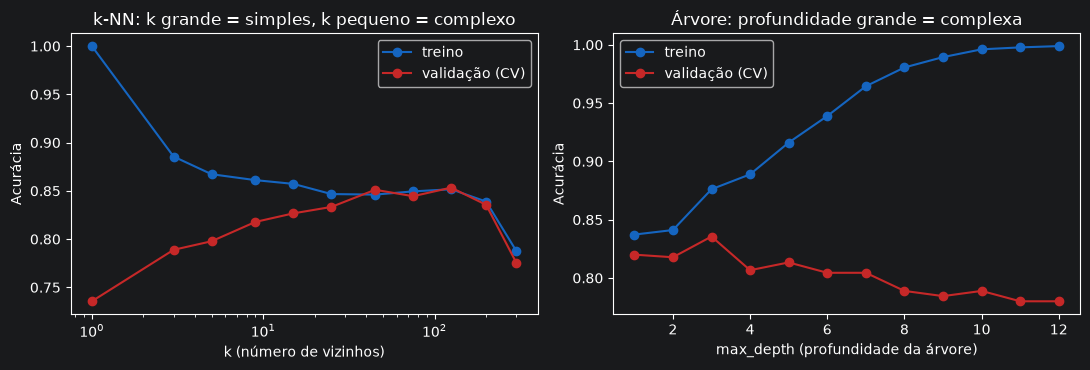

In [3]:
ks = [1, 3, 5, 9, 15, 25, 45, 75, 125, 200, 300]
tr_k, va_k = validation_curve(com_prep(KNeighborsClassifier()), X, y,
                              param_name="modelo__n_neighbors", param_range=ks, cv=validacao)
profs = list(range(1, 13))
tr_d, va_d = validation_curve(com_prep(DecisionTreeClassifier(random_state=SEMENTE)), X, y,
                              param_name="modelo__max_depth", param_range=profs, cv=validacao)

display(pd.DataFrame({"k": ks, "treino": tr_k.mean(1), "validação": va_k.mean(1)}).round(3))

fig, eixos = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, xs, tr, va, xlabel, log in [
    (eixos[0], ks, tr_k, va_k, "k (número de vizinhos)", True),
    (eixos[1], profs, tr_d, va_d, "max_depth (profundidade da árvore)", False),
]:
    ax.plot(xs, tr.mean(1), "o-", color="#1565c0", label="treino")
    ax.plot(xs, va.mean(1), "o-", color="#c62828", label="validação (CV)")
    ax.set_xlabel(xlabel); ax.set_ylabel("Acurácia"); ax.legend()
    if log:
        ax.set_xscale("log")
eixos[0].set_title("k-NN: k grande = simples, k pequeno = complexo")
eixos[1].set_title("Árvore: profundidade grande = complexa")
plt.tight_layout(); plt.show()

**Como ler.**

- **Sobreajuste:** k=1 acerta 100% do treino mas só ~74% na validação — grande distância entre as curvas. Na árvore, a curva de treino sobe até ~1,0 enquanto a de validação cai.
- **Subajuste:** k=300 usa mais de 80% do treino como vizinhos e as **duas** curvas caem — o modelo é simples demais até para o treino.
- O melhor `k` fica onde a curva de **validação** é mais alta (um patamar entre ~45 e ~125).

## 2. Curva de aprendizado

Agora variamos a **quantidade de dados de treino** e observamos treino × validação. Ela responde: *mais dados ajudam?*

Regressão logística (simples)


,n_treino,treino,validação
0,36,0.961,0.809
1,72,0.936,0.820
2,144,0.872,0.844
3,216,0.872,0.851
4,288,0.875,0.851
5,360,0.861,0.856


Árvore sem limite (complexa)


,n_treino,treino,validação
0,36,1.0,0.731
1,72,1.0,0.740
2,144,1.0,0.787
3,216,1.0,0.796
4,288,1.0,0.762
5,360,1.0,0.778


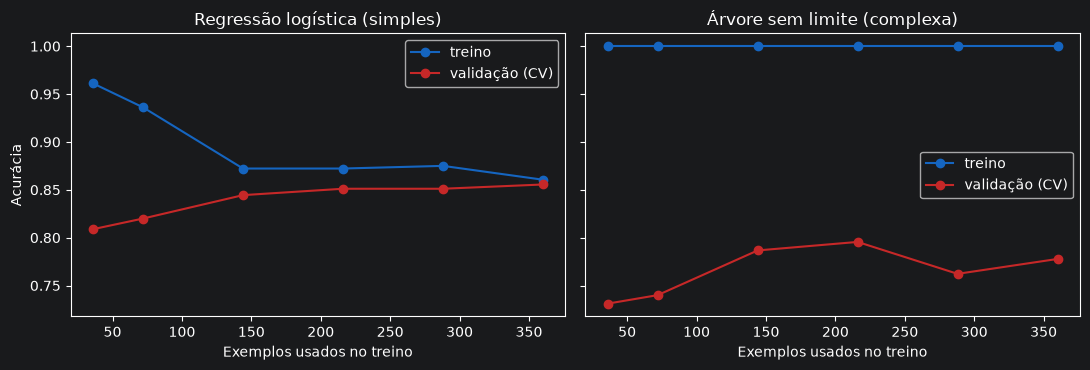

In [4]:
tamanhos = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
fig, eixos = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, (nome, modelo) in zip(eixos, [
    ("Regressão logística (simples)", LogisticRegression(max_iter=1000)),
    ("Árvore sem limite (complexa)", DecisionTreeClassifier(random_state=SEMENTE)),
]):
    n_ex, tr, va = learning_curve(com_prep(modelo), X, y, train_sizes=tamanhos, cv=validacao)
    print(nome)
    display(pd.DataFrame({"n_treino": n_ex, "treino": tr.mean(1), "validação": va.mean(1)}).round(3))
    ax.plot(n_ex, tr.mean(1), "o-", color="#1565c0", label="treino")
    ax.plot(n_ex, va.mean(1), "o-", color="#c62828", label="validação (CV)")
    ax.set_title(nome); ax.set_xlabel("Exemplos usados no treino"); ax.legend()
eixos[0].set_ylabel("Acurácia")
plt.tight_layout(); plt.show()

**Como ler.**

| Padrão | Diagnóstico | Cura provável |
|---|---|---|
| Treino e validação **convergem** em valor parecido (regressão logística, ~0,86) | pouco sobreajuste; o limite está no **modelo** | modelo mais rico, mais atributos |
| **Grande lacuna** entre treino (=1,0) e validação (0,73–0,80) (árvore sem limite) | **variância alta** (sobreajuste) | modelo mais simples, mais dados, regularização |
| Ambas as curvas **baixas** e juntas | **viés alto** (subajuste) | modelo mais flexível |

### Para praticar
1. Refaça a curva de complexidade com `SVC(kernel="rbf")` variando `C` em `[0.01, 0.1, 1, 10, 100]`.
2. Em qual região de `C` está o sobreajuste? E o subajuste?